# This notebook is used to plot curvefit for the subtlety data (april sess 1 and 2)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from scipy.stats import ttest_rel,wilcoxon
path_to_add = os.path.abspath('../')
sys.path.append(path_to_add)
from func_fix_curvefit_params import *
import os

In [2]:
path_to_add = os.path.abspath('../')
path_to_add

'/Users/f0053cz/Dartmouth College Dropbox/Rekha Sreekumar Varrier/postdoc_Dartmouth/psyanim_behav_paper/version2/scripts_data_for_beh_paper/code'

In [3]:
sys.path.append(path_to_add)
from func_curvefit import *
import seaborn as sns

In [4]:
root_data_file = '../../data/subtlety_data'

In [5]:
## import dataframes (curvefit)
df_params_test = pd.read_csv(f'{root_data_file}/curve_fit_subt_ses1/all_params_1k_subt.csv')
df_params_retest = pd.read_csv(f'{root_data_file}/curve_fit_subt_ses2/all_params_1k_subt.csv')
df_params_test.shape, df_params_retest.shape

((312, 12), (240, 12))

In [6]:
df_params_test = fix_obj_center(df_params_test)
df_params_retest = fix_obj_center(df_params_retest)

In [7]:
## import raw dataframes (rating)
df_data_test = pd.read_csv(f'{root_data_file}/all_apr_ses1.csv')
df_data_retest = pd.read_csv(f'{root_data_file}/all_apr_ses2.csv')
df_data_test.shape, df_data_retest.shape

((26208, 10), (20160, 8))

In [8]:
## merging the two curvefit params dataframe
df_params_merge = df_params_test.merge(df_params_retest, on = 'subID', suffixes = ('_ses1', '_ses2'))
df_params_merge.head()

,subID,r_squared_ses1,nrmse_ses1,aic_ses1,center_ses1,obj_center_ses1,sigma_ses1,bias_xmin_ses1,bias_xmax_ses1,bias_lower_ses1,...,nrmse_ses2,aic_ses2,center_ses2,obj_center_ses2,sigma_ses2,bias_xmin_ses2,bias_xmax_ses2,bias_lower_ses2,bias_upper_ses2,flipped_ses2
0,2.0,0.994396,0.030065,-45.061484,0.395356,0.379090,0.106477,0.092967,0.003165,0.070833,...,0.053215,-37.067887,0.437272,0.379686,0.132783,0.226559,0.046721,0.199167,0.035833,False
1,4.0,0.990862,0.036692,-42.272749,0.353184,0.288929,0.114098,0.322398,0.147745,0.298333,...,0.049461,-38.092011,0.493091,0.375676,0.138347,0.373690,0.186597,0.360909,0.175000,False
2,5.0,0.976299,0.064073,-34.468260,0.537650,0.506901,0.093353,0.165036,0.036492,0.162500,...,0.006915,-65.636911,0.492211,0.385977,0.093328,0.385784,0.137909,0.383333,0.135833,False
3,6.0,0.969141,0.061998,-34.929123,0.252783,0.187152,0.121123,0.296448,0.001652,0.209167,...,0.041230,-40.640351,0.475595,0.326023,0.130284,0.426422,0.246824,0.417778,0.240833,False
4,7.0,0.994388,0.030773,-44.735717,0.448519,0.419016,0.087977,0.188766,0.059766,0.184167,...,0.056519,-36.224397,0.492990,0.433843,0.083456,0.289247,0.069811,0.287500,0.068333,False


In [12]:
print('before:',df_params_merge.shape)
df_params_merge.dropna(inplace=True)
df_params_merge.shape

before: (240, 23)


(240, 23)

## Plotting all results: curves & ratings from ses 1 and ses 2

In [13]:
rootfile_results = '../../results/subtlety/refit_across_sessions'

In [14]:
# filter behavioral scores
df_data_ses1 = df_data_test.loc[:, df_data_test.columns != 'stim_file']
df_data_ses2 = df_data_retest.loc[:, df_data_retest.columns != 'stim_file']

## preprocess the dataframe
df_data_ses1 = df_data_test.loc[:, df_data_test.columns != 'stim_file']
df_data_ses1 = df_data_ses1.drop(['condition'], axis=1)
df_data_ses1 = df_data_ses1.groupby(['subID','subtlety']).mean().reset_index()

df_data_ses2 = df_data_retest.loc[:, df_data_retest.columns != 'stim_file']
df_data_ses2 = df_data_ses2.drop(['condition'], axis=1)
df_data_ses2 = df_data_ses2.groupby(['subID','subtlety']).mean().reset_index()

In [15]:
## merging the two rating df 
df_rating_merge = df_data_ses1.merge(df_data_ses2, on=['subID', 'subtlety'], suffixes = ('_ses1', '_ses2'))
df_rating_merge.head()

,subID,subtlety,slider_ses1,RT_ses1,accuracy_ses1,trial_ind_ses1,slider_ses2,RT_ses2,accuracy_ses2,trial_ind_ses2
0,2,0,100.000000,2.906250,1.000000,42.833333,96.416667,2.580917,1.0,37.416667
1,2,30,98.666667,3.372250,1.000000,49.166667,90.250000,2.551667,1.0,44.750000
2,2,60,96.333333,3.131917,1.000000,44.416667,82.250000,2.498750,1.0,48.083333
3,2,90,70.666667,2.610833,1.000000,49.583333,67.000000,2.430500,1.0,37.083333
4,2,120,44.333333,3.442833,0.916667,27.666667,50.000000,2.943750,1.0,40.250000


In [16]:
df_rating_merge = df_rating_merge.loc[df_rating_merge['subID'].isin(df_params_merge['subID']),:]
df_rating_merge

,subID,subtlety,slider_ses1,RT_ses1,accuracy_ses1,trial_ind_ses1,slider_ses2,RT_ses2,accuracy_ses2,trial_ind_ses2
0,2,0,100.000000,2.906250,1.000000,42.833333,96.416667,2.580917,1.000000,37.416667
1,2,30,98.666667,3.372250,1.000000,49.166667,90.250000,2.551667,1.000000,44.750000
2,2,60,96.333333,3.131917,1.000000,44.416667,82.250000,2.498750,1.000000,48.083333
3,2,90,70.666667,2.610833,1.000000,49.583333,67.000000,2.430500,1.000000,37.083333
4,2,120,44.333333,3.442833,0.916667,27.666667,50.000000,2.943750,1.000000,40.250000
...,...,...,...,...,...,...,...,...,...,...
1675,344,60,87.500000,2.451833,1.000000,36.250000,98.000000,2.563333,1.000000,40.416667
1676,344,90,68.916667,2.384417,0.916667,46.750000,69.833333,2.555083,1.000000,39.583333
1677,344,120,31.833333,2.124750,0.833333,51.666667,42.916667,2.930250,0.833333,42.583333
1678,344,150,20.250000,1.966000,0.583333,39.833333,22.000000,2.597667,0.666667,41.000000


## Fitting own data from one session to another

In [18]:
s=16 # CHANGE FONTSIZE HERE
plt.rc('font', size=s) #controls default text size
plt.rc('axes', titlesize=s) #fontsize of the title
plt.rc('axes', labelsize=s) #fontsize of the x and y labels
plt.rc('xtick', labelsize=s) #fontsize of the x tick labels
plt.rc('ytick', labelsize=s) #fontsize of the y tick labels
plt.rc('legend', fontsize=s) #fontsize of the legend

In [18]:
# function that plots refit graph for self
def plot_refit_curvefit_self(nrows, ncols, df_params, df_rating, param_ses, rating_ses, flname,title):#, r2_list, rmse_list):
    # arguments: 
    # nrow,ncol - nr of rows and columns in the plot
    # df_params, df_rating: curve fit param and raw data dataframes
    # param_ses: train session, rating_ses: test ses
    # flname: full filename to save results in
    # ((not there anymore: r2_list, rmse_list - empty lists to store r1 and rmse in))
    # ((returning: nothing. the r2 and rmse lists update outside the function automatically))
    # returning: dataframe with subID, r2 and rmse

    r2_list = []
    rmse_list = []
    subID_all = []
    fig,axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*2,nrows*2.1), sharey=True,sharex=True)#(20, 70))
    
    # for isub in range(350):
    for isub,subID in enumerate(df_params_merge['subID']):
        # print(isub,subID)
        # ax = plt.subplot(nrows, ncols, isub)
        r = int(np.floor(isub/ncols))
        c = isub%ncols
        ax = axs[r,c]
        ax.set_xlim(-0.05, 1.05)
        ax.set_ylim(-0.05, 1.05)

        # subID =  isub+1

        if isub%50 == 0:
            print('subID=',subID)

        # try:
        # behavior
        xfit = (180 - df_rating.loc[df_rating['subID'] ==subID, 'subtlety'].values) / 180
        yfit = df_rating.loc[df_rating['subID'] == subID, f'slider_ses{rating_ses}'].values / 100
        
        # print(xfit)
        x = np.array(xfit)
        y = np.array(yfit)

        # Plot behavioral dots
        ax.plot(x, y, '.', alpha=0.5, color='black')

        intercept = df_params_merge.loc[df_params_merge['subID'] == subID, f'bias_xmin_ses{param_ses}'].values
        center = df_params_merge.loc[df_params_merge['subID'] == subID, f'center_ses{param_ses}'].values
        sigma = df_params_merge.loc[df_params_merge['subID'] == subID, f'sigma_ses{param_ses}'].values
        bias_upper = df_params_merge.loc[df_params_merge['subID'] == subID, f'bias_xmax_ses{param_ses}'].values

        amplitude = 1 - intercept - bias_upper
        x_values = np.linspace(np.nanmin(x), np.nanmax(x), 100)
        y_values = intercept + amplitude * sigmoid(x_values, sigma, center)

        # Plot the curves
        ax.plot(x_values, y_values, '-', color='tab:blue')

        # Calculate the r_squared and rmse
        y_pred = intercept + amplitude * sigmoid(x, sigma, center)
        r_sq = r_squared(y, y_pred)
        rmse = normalized_error(y, y_pred)

        r2_list.append(r_sq)
        rmse_list.append(rmse)
        subID_all.append(subID)

        if rmse <= 0.2:
            color = 'k'
        else:
            color = 'r'
        ax.set_title(f'Subject {subID}')
        ax.annotate("r_2: %.2f" % r_sq, xy=(1, 0.2), xycoords ='axes fraction', color=color,ha='right')
        ax.annotate("rmse: %.2f" % rmse, xy=(1, 0), xycoords ='axes fraction', color=color,ha='right')

        # except:
        #     print('isub, error!')
        #     plt.delaxes(ax)  
        #     r2_list.append(np.nan) # to keep list the same length as df
        #     rmse_list.append(np.nan)
        #     subID_all.append(subID)      
        
        ax.set_xticks([0,1],['180','0'])
   

    for isub in np.arange(df_params_merge.shape[0],nrows*ncols):
        ax =  plt.subplot(nrows, ncols, isub + 1)
        plt.delaxes(ax)  

    plt.suptitle(title, fontweight='bold',fontsize=24)
    plt.tight_layout() 
    # plt.subplots_adjust(wspace=0.5, hspace=0.5) 
    plt.savefig(flname, facecolor='w')
    plt.clf()
    
    df = pd.DataFrame({'subID':subID_all,'R2':r2_list, 'RMSE': rmse_list})
    
    return df

In [19]:
nrows, ncols = 12, 20

In [20]:
rootfile_results

'../../results/subtlety/refit_across_sessions'

In [19]:
load_data = 1 # enter 0 to not load (and compute params) and 1 to load csv

In [21]:
# Fitting ses 1 (curvefit param) to ses 1 (behavioral rating)
# self_r_sqaure_ses1_t_ses1 = []
# self_rmse_ses1_t_ses1 = []

if load_data:
    self_fit_ses1= pd.read_csv('../../data/subtlety_data/refit/self_fit_ses1.csv')
else:
    title = 'ses1_to_ses1'
    flname = f'{rootfile_results}/sublevel/{title}_sublevel.png' # fits of x session to y data
    self_fit_ses1 = plot_refit_curvefit_self(nrows, ncols, df_params_merge, df_rating_merge,
                        1, 1,flname,title)#, self_r_sqaure_ses1_t_ses1, self_rmse_ses1_t_ses1)
    self_fit_ses1.to_csv('../../data/subtlety_data/refit/self_fit_ses1.csv')
self_fit_ses1.head()

,Unnamed: 0,subID,R2,RMSE
0,0,2.0,0.992434,0.036298
1,1,4.0,0.986982,0.044801
2,2,5.0,0.976678,0.063949
3,3,6.0,0.948490,0.087599
4,4,7.0,0.994742,0.030120


In [23]:
# Fitting ses 2  (curvefit param) to ses 2 (behavioral rating)
# self_r_sqaure_ses2_t_ses2 = []
# self_rmse_ses2_t_ses2 = []

if load_data:
    self_fit_ses2= pd.read_csv('../../data/subtlety_data/refit/self_fit_ses2.csv')
else:
    title = 'ses2_to_ses2' 
    flname = f'{rootfile_results}/sublevel/{title}_sublevel.png'
    self_fit_ses2 = plot_refit_curvefit_self(nrows, ncols, df_params_merge, df_rating_merge,
                        2, 2, flname,title) #self_r_sqaure_ses2_t_ses2, self_rmse_ses2_t_ses2)
    self_fit_ses2.to_csv('../../data/subtlety_data/refit/self_fit_ses2.csv')
self_fit_ses2.head()

,Unnamed: 0,subID,R2,RMSE
0,0,2.0,0.977420,0.062135
1,1,4.0,0.979402,0.053182
2,2,5.0,0.999678,0.007863
3,3,6.0,0.986886,0.045191
4,4,7.0,0.985099,0.056098


In [25]:
# Fitting ses 1 (curvefit param) to ses 2 (behavioral rating)
# self_r_sqaure_ses1_t_ses2 = []
# self_rmse_ses1_t_ses2 = []
if load_data:
    cross_fit_ses1to2= pd.read_csv('../../data/subtlety_data/refit/cross_fit_ses1to2.csv')
else:
    title = 'ses1_to_ses2' 
    flname = f'{rootfile_results}/sublevel/{title}_sublevel.png'
    cross_fit_ses1to2 = plot_refit_curvefit_self(nrows, ncols, df_params_merge, df_rating_merge,
                        1, 2,flname,title) #, self_r_sqaure_ses1_t_ses2, self_rmse_ses1_t_ses2)
    cross_fit_ses1to2.to_csv('../../data/subtlety_data/refit/cross_fit_ses1to2.csv')          
cross_fit_ses1to2.head()          

,Unnamed: 0,subID,R2,RMSE
0,0,2.0,0.935569,0.099114
1,1,4.0,0.889970,0.174404
2,2,5.0,0.549697,0.330833
3,3,6.0,0.128970,0.683820
4,4,7.0,0.948240,0.093473


In [26]:
# Fitting ses 2 (curvefit param) to ses 1 (behavioral rating)
# self_r_sqaure_ses2_t_ses1 = []
# self_rmse_ses2_t_ses1 = []
if load_data:
    cross_fit_ses2to1= pd.read_csv('../../data/subtlety_data/refit/cross_fit_ses2to1.csv')
else:
    title = 'ses2_to_ses1'
    flname = f'{rootfile_results}/sublevel/{title}_sublevel.png'
    cross_fit_ses2to1 = plot_refit_curvefit_self(nrows, ncols, df_params_merge, df_rating_merge,
                        2, 1, flname,title)#, self_r_sqaure_ses2_t_ses1, self_rmse_ses2_t_ses1)
    cross_fit_ses2to1.to_csv('../../data/subtlety_data/refit/cross_fit_ses2to1.csv')
cross_fit_ses2to1.head()

,Unnamed: 0,subID,R2,RMSE
0,0,2.0,0.912496,0.119138
1,1,4.0,0.890131,0.156528
2,2,5.0,0.815692,0.198426
3,3,6.0,0.608664,0.305038
4,4,7.0,0.970462,0.074995


## Fitting mean of all other participants to self

In [27]:
## fit the mean to self
def plot_refit_curvefit_mean(nrows, ncols, df_params, df_rating, param_ses, rating_ses, flname,title):#, r2_list, rmse_list):
    # compares each sub's true data (test) to mean data from another session excluding that sub(train)
    
    # arguments: 
    # nrow,ncol - nr of rows and columns in the plot
    # df_params, df_rating: curve fit param and raw data dataframes
    # param_ses: train session, rating_ses: test ses
    # flname: full filename to save results in
    # ((not there anymore: r2_list, rmse_list - empty lists to store r1 and rmse in))
    # ((returning: nothing. the r2 and rmse lists update outside the function automatically))
    # returning: dataframe with subID, r2 and rmse

    subID_all = []
    r2_list = []
    rmse_list = []

    # plt.subplots(nrows=nrow, ncols=ncol, figsize=(20, 70))
    fig,axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*3.25,nrows*3), sharey=True,sharex=True)#(20, 70))
    
    for isub,subID in enumerate(df_params_merge['subID']):
    # for isub in range(350):
        r = int(np.floor(isub/ncols))
        c = isub%ncols
        ax = axs[r,c]
        # ax = plt.subplot(nrow, ncol, isub + 1)
        ax.set_xlim(-0.05, 1.05)
        ax.set_ylim(-0.05, 1.05)

        if isub%50==0:
            print('subID=',subID)

        # try:
        # behavior
        xfit = (180 - df_rating.loc[df_rating['subID'] == subID, 'subtlety'].values) / 180
        yfit = df_rating.loc[df_rating['subID'] == subID, f'slider_ses{rating_ses}'].values / 100
        
        x = np.array(xfit)
        y = np.array(yfit)

        # Plot behavioral dots
        ax.plot(x, y, '.', alpha=0.5, color='black')

        df_temp = df_params_merge[df_params_merge['subID'] != subID].copy() # exclude current sub
        # other_mean: curve fit
        param_mean = df_temp.mean()

        intercept = param_mean[f'bias_xmin_ses{param_ses}']
        center = param_mean[f'center_ses{param_ses}']
        sigma = param_mean[f'sigma_ses{param_ses}']
        bias_upper = param_mean[f'bias_xmax_ses{param_ses}']
        amplitude = 1 - intercept - bias_upper
    
        x_values = np.linspace(np.nanmin(x), np.nanmax(x), 100)
        y_values = intercept + amplitude * sigmoid(x_values, sigma, center)
        # Plot the curves
        ax.plot(x_values, y_values, '-', color='tab:blue')

        # Calculate the r_squared and rmse
        y_pred = intercept + amplitude * sigmoid(x, sigma, center)
        r_sq = r_squared(y, y_pred)
        rmse = normalized_error(y, y_pred)

        r2_list.append(r_sq)
        rmse_list.append(rmse)
        subID_all.append(subID)

        if rmse <= 0.2:
            color = 'k'
        else:
            color = 'r'

        ax.set_title(f'Subject {subID}')
        ax.annotate("r_2: %.2f" % r_sq, xy=(1, 0.2), xycoords ='axes fraction', color=color,ha='right')
        ax.annotate("rmse: %.2f" % rmse, xy=(1, 0), xycoords ='axes fraction', color=color,ha='right')

        # except:
        #     plt.delaxes(ax)  
        #     r2_list.append(np.nan) # to keep list the same length as df
        #     rmse_list.append(np.nan)

    ax.set_xticks([0,1],['180','0'])
    ax.set_yticks([0,0.5,1])
   
    for isub in np.arange(df_params_merge.shape[0],nrows*ncols):
        ax =  plt.subplot(nrows, ncols, isub + 1)
        plt.delaxes(ax)  

    plt.suptitle(title, fontweight='bold',fontsize=24)
    plt.tight_layout() 
    # plt.subplots_adjust(wspace=0.5, hspace=0.5) 
    plt.savefig(flname, facecolor='w')
    plt.clf()

    df = pd.DataFrame({'subID':subID_all,'R2':r2_list, 'RMSE': rmse_list})
    
    return df

In [28]:
# fit mean to self: ses 1 mean (curvit) to ses 1 self(rating)
# mean_r_sqaure_ses1_t_ses1 = []
# mean_rmse_ses1_t_ses1 = []
if load_data:
    self_fit_mean_ses1= pd.read_csv('../../data/subtlety_data/refit/self_fit_mean_ses1.csv')
else:
    title = 'ses1mean_to_ses1'
    flname = f'{rootfile_results}/mean/{title}_mean.png'
    self_fit_mean_ses1 = plot_refit_curvefit_mean(nrows, ncols, df_params_merge, df_rating_merge,
                        1, 1,flname,title)#, mean_r_sqaure_ses1_t_ses1, mean_rmse_ses1_t_ses1)
    self_fit_mean_ses1.to_csv('../../data/subtlety_data/refit/self_fit_mean_ses1.csv')
self_fit_mean_ses1.head()

,Unnamed: 0,subID,R2,RMSE
0,0,2.0,0.929965,0.107298
1,1,4.0,0.874195,0.138390
2,2,5.0,0.891170,0.167534
3,3,6.0,0.874729,0.208875
4,4,7.0,0.980744,0.076250


In [30]:
# fit mean to self: ses 2 mean (curvefit) to ses 2 self(rating)
# mean_r_sqaure_ses2_t_ses2 = []
# mean_rmse_ses2_t_ses2 = []
if load_data:
    self_fit_mean_ses2= pd.read_csv('../../data/subtlety_data/refit/self_fit_mean_ses2.csv')
else:
    title = 'ses2mean_to_ses2'
    flname = f'{rootfile_results}/mean/{title}_mean.png'
    self_fit_mean_ses2 = plot_refit_curvefit_mean(nrows, ncols, df_params_merge, df_rating_merge,
                        2, 2,flname,title)#, mean_r_sqaure_ses2_t_ses2, mean_rmse_ses2_t_ses2)
    self_fit_mean_ses2.to_csv('../../data/subtlety_data/refit/self_fit_mean_ses2.csv')
self_fit_mean_ses2.head()

,Unnamed: 0,subID,R2,RMSE
0,0,2.0,0.972237,0.072300
1,1,4.0,0.618120,0.245180
2,2,5.0,0.835879,0.168385
3,3,6.0,-0.227545,0.437579
4,4,7.0,0.962174,0.100078


## compare the rmse between conditions

### ses 1 to ses 1

### ses 1 to ses 2

### ses 2 to ses 2

### ses 2 to ses 1

In [46]:
# Define a function to remove outliers based on 3*std deviation
def remove_outliers_std(df, columns):
    for col in columns:
        # print(df[col])
        mean = df[col].mean()
        std_dev = df[col].std()
        
        lower_bound = mean - 3 * std_dev
        upper_bound = mean + 3 * std_dev
        
        # Remove rows where column values are outliers
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    
    return df


In [58]:
def plot_pval(p):
    if p < .001:
        return '***'
    elif p < .01:
        return '**'
    elif p < .05:
        return '*'
    elif p < .1:
        return '.'
    else:
        print('not significant')

In [111]:
def return_stats(x,y):
    t,p = ttest_rel(x,y)
    MD = (x-y).mean()
    return MD,t,p

def plot_rmse_dist_4_plots(self, self_altses, mean, flname, title,ylabel):
# def plot_rmse_dist_4_plots(self, self_altses, mean, mean_altses, flname, title,ylabel):
    # params = ['other_ind_mean', 'other_ind_median', 'other_ind_min']
    df_bootstrap = pd.DataFrame()
    df_bootstrap['self_sameses'] =[x for x in self if not np.isnan(x)]
    df_bootstrap['self_altses'] =[x for x in self_altses if not np.isnan(x)]
    df_bootstrap['mean_sameses'] = [x for x in mean if not np.isnan(x)]
    # df_bootstrap['mean_altses'] = [x for x in mean_altses if not np.isnan(x)]
    
    stats_array = np.full((3,3),np.nan) #MD,t,p
    count = -1
    all_grps = ['self_sameses', 'self_altses','mean_sameses']#,'mean_altses']
    # lbls = []
    for i,param1 in enumerate(all_grps[:-1]):
        for j,param2 in enumerate(all_grps[i+1:]):
            # print(i,j)
            count += 1
            x = df_bootstrap[param1]
            y = df_bootstrap[param2]
            stats_array[count,:] = return_stats(x,y)
            print(f'{count}. param1:{param1},param2:{param2},MD:{stats_array[count,0]:.2f},t={stats_array[count,1]:.2f} ({get_p(stats_array[count,2])})')

    # for param in params: #  ['other_ind_mean', 'other_ind_median', 'other_ind_min']
    plt.figure(figsize=(5, 3))
    data_list = [df_bootstrap['self_sameses'], df_bootstrap['self_altses'], df_bootstrap['mean_sameses']]#, df_bootstrap['mean_altses']]
    positions = [0,1,2]#,3]    

    # Remove outliers
    data_list = remove_outliers_std(df_bootstrap, all_grps)

    parts = plt.violinplot(data_list, positions=positions, showmeans=True)
    # print(parts['bodies'])

    # Customize the body color
    for i,pc in enumerate(parts['bodies']):
        pc.set_facecolor('tab:blue')
        pc.set_edgecolor('black')

        pc.set_linewidth(3)
        pc.set_alpha(0.5)

    # Customize the mean line color
    parts['cmeans'].set_edgecolor('k')

    # Customize the minimum and maximum lines color
    parts['cmins'].set_edgecolor('k')
    parts['cmaxes'].set_edgecolor('k')
    
    plt.plot(data_list.T,color = 'grey',alpha=.1)
    lbls = ['12','13','23']
    ypos = .95
    p_values = []
    for i in range(stats_array.shape[0]):
        MD = stats_array[i,0]
        p = stats_array[i,2]
        txt = f'MD{lbls[i]}={MD:.2f}(t-test:{get_p(p)})'  #,\nwilc.:{get_p(p_wilc)})'
        # plt.gca().annotate(txt, xy=(0.05,ypos),ha='left',va='top',xycoords='axes fraction')
        ypos = ypos - .08
        p_values.append(p)
    
    plt.title(title, fontweight='bold')
    plt.xticks(positions, ['same\nparticipant,\nsame\nsession', 'same\nparticipant,\ndifferent\nsession', \
        "different\nparticipants,\nsame\nsession"],fontsize=14)#, "mean params\nfrom others\n(across sess;\ntest set)"])
    print(f'Self v mean:')
    plt.ylim(-.1,.8)
    plt.xlim(-.5,2.5)
    
    # since p <.001 in all 3 cases. check this for all indiv comparisons in the printed results!!!
    plt.hlines(0.6,0,.9,color = 'k',linewidth = .5)
    plt.gca().annotate(plot_pval(p_values[0]), xy=(0.45,.60), color='k',ha='center') 
    plt.hlines(0.6,1.1,2,color = 'k',linewidth = .5)
    plt.gca().annotate(plot_pval(p_values[2]), xy=(1.5, 0.60), color='k',ha='center')
    plt.hlines(0.702,0,2,color = 'k',linewidth = .5)
    plt.gca().annotate(plot_pval(p_values[1]), xy=(1, 0.70), color='k',ha='center')
    plt.ylabel(ylabel)
    plt.savefig(flname + '.png', bbox_inches='tight',dpi=300)

In [112]:
s=16 # CHANGE FONTSIZE HERE
plt.rc('font', size=s) #controls default text size
plt.rc('axes', titlesize=s) #fontsize of the title
plt.rc('axes', labelsize=s) #fontsize of the x and y labels
plt.rc('xtick', labelsize=s) #fontsize of the x tick labels
plt.rc('ytick', labelsize=s) #fontsize of the y tick labels
plt.rc('legend', fontsize=s) #fontsize of the legend

0. param1:self_sameses,param2:self_altses,MD:-0.08,t=-22.13 (p < .001)
1. param1:self_sameses,param2:mean_sameses,MD:-0.13,t=-14.50 (p < .001)
2. param1:self_altses,param2:mean_sameses,MD:-0.04,t=-4.74 (p < .001)
Self v mean:


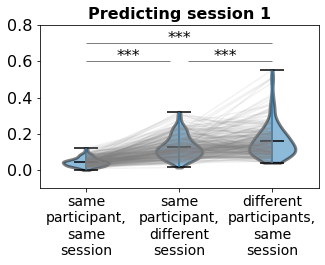

In [113]:
# plot_rmse_dist(self_rmse_ses1_t_ses2, mean_rmse_ses1_t_ses2, other_rmse_ses1_t_ses2, 'ses 1 to ses 2')
title = 'Predicting session 1'# es1_to_ses2_all4
ylabel = ''#'Error in predicting ses1'
flname = f'{rootfile_results}/predicting_session1'
plot_rmse_dist_4_plots(self_fit_ses1['RMSE'], cross_fit_ses2to1['RMSE'], self_fit_mean_ses1['RMSE'], flname, title,ylabel)

In [114]:
rootfile_results

'../../results/subtlety/refit_across_sessions'

0. param1:self_sameses,param2:self_altses,MD:-0.09,t=-17.50 (p < .001)
1. param1:self_sameses,param2:mean_sameses,MD:-0.14,t=-12.56 (p < .001)
2. param1:self_altses,param2:mean_sameses,MD:-0.05,t=-4.82 (p < .001)
Self v mean:


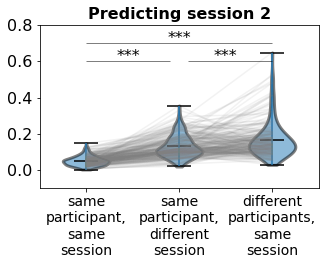

In [115]:
# plot_rmse_dist(self_rmse_ses1_t_ses2, mean_rmse_ses1_t_ses2, other_rmse_ses1_t_ses2, 'ses 1 to ses 2')
title = 'Predicting session 2'# es1_to_ses2_all4
flname = f'{rootfile_results}/predicting_session2'
ylabel = ''#'Error in predicting ses2'
plot_rmse_dist_4_plots(self_fit_ses2['RMSE'], cross_fit_ses1to2['RMSE'], self_fit_mean_ses2['RMSE'], flname, title,ylabel)


## comparision between fits for self vs mean & ind_min

In [44]:
def remove_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df

def plot_sep_dist(self, mean, other, ses_to_ses, remove_outlier):
    df_bootstrap = pd.DataFrame()
    df_bootstrap['self'] =[x for x in self if not np.isnan(x)]
    df_bootstrap['mean'] = [x for x in mean if not np.isnan(x)]
    df_bootstrap['other_ind_min'] = get_other_param(other, 'min')
    
    # trim the dataframe so that can exlude outliers
    if remove_outlier == True:
        df_bootstrap = remove_outliers(df_bootstrap, ['self', 'mean', 'other_ind_min'])

    ###### plot self vs. mean
    plt.figure(figsize=(10, 5))
    plt.boxplot([df_bootstrap['self'], df_bootstrap['mean']], positions=[0, 1])
    violin1 = sns.violinplot(data=df_bootstrap[['self', 'mean']], palette=['tab:red', 'tab:blue'], inner=None)
    
    for collection in violin1.collections:
        collection.set_alpha(0.5)
        
    plt.scatter([0] * len(df_bootstrap['self']), df_bootstrap['self'], 
                color='tab:red', alpha = 0.1, label='self')
    plt.scatter([1] * len(df_bootstrap['mean']), df_bootstrap['mean'], 
                color='tab:blue', alpha = 0.1, label='mean')
    min_len = min(len(df_bootstrap['self']), len(df_bootstrap['mean']))
    for i in range(min_len):
        plt.plot([0, 1], [df_bootstrap['self'].iloc[i], df_bootstrap['mean'].iloc[i]], 
                 color='gray', linestyle='--', alpha=0.1)
    
    plt.title(f'Distribution of refitted rsme ({ses_to_ses}) \n self vs mean')
    t_stat, p_value = ttest_rel(df_bootstrap['self'], df_bootstrap['mean'])
    plt.xticks([0, 1], ['self', 'mean'])
    plt.text(0.35, -0.02, f't-test: {t_stat:.2f}, p-value: {p_value:.2f}')
    plt.show()
    
    
    
    ######## plot self vs. ind_min
    plt.figure(figsize=(10, 5))
    plt.boxplot([df_bootstrap['self'], df_bootstrap['other_ind_min']], positions=[0, 1])
    violin2 = sns.violinplot(data=df_bootstrap[['self', 'other_ind_min']], positions=[1,2], 
                   palette=['tab:red', 'tab:green'], inner=None)
    
    for collection in violin2.collections:
        collection.set_alpha(0.5)
    plt.scatter([0] * len(df_bootstrap['self']), df_bootstrap['self'], 
                color='tab:red', alpha = 0.1, label='self')
    plt.scatter([1] * len(df_bootstrap['other_ind_min']), df_bootstrap['other_ind_min'], 
                color='tab:green', alpha = 0.1, label='other_ind_min')
    min_len = min(len(df_bootstrap['self']), len(df_bootstrap['other_ind_min']))
    for i in range(min_len):
        plt.plot([0, 1], [df_bootstrap['self'].iloc[i], df_bootstrap['other_ind_min'].iloc[i]], 
                 color='gray', linestyle='--', alpha=0.1)
    
    
    plt.title(f'Distribution of refitted rsme ({ses_to_ses}) \n self vs other_ind_min')
    t_stat, p_value = ttest_rel(df_bootstrap['self'], df_bootstrap['other_ind_min'])
    plt.xticks([0, 1], ['self', 'other_ind_min'])
    plt.text(0.35, -0.015, f't-test: {t_stat:.2f}, p-value: {p_value:.2f}')
    plt.show()

### ses 1 to ses 1

In [45]:
plot_sep_dist(self_rmse_ses1_t_ses1, mean_rmse_ses1_t_ses1, other_rmse_ses1_t_ses1, 'ses 1 to ses 1', False)

NameError: name 'self_rmse_ses1_t_ses1' is not defined

### ses 1 to ses 2

In [ ]:
plot_sep_dist(self_rmse_ses1_t_ses2, mean_rmse_ses1_t_ses2, other_rmse_ses1_t_ses2, 'ses 1 to ses 2', False)

### ses 2 to ses 2

In [ ]:
plot_sep_dist(self_rmse_ses2_t_ses2, mean_rmse_ses2_t_ses2, other_rmse_ses2_t_ses2, 'ses 2 to ses 2', False)

### ses 2 to ses 1

In [ ]:
plot_sep_dist(self_rmse_ses2_t_ses1, mean_rmse_ses2_t_ses1, other_rmse_ses2_t_ses1, 'ses 2 to ses 1', False)

## plot between self-->self to see if one session fit is better than another

In [ ]:
plt.figure(figsize=(10, 5))
self_rmse_ses1_t_ses2_clean = [x for x in self_rmse_ses1_t_ses2 if not np.isnan(x)]
self_rmse_ses2_t_ses1_clean = [x for x in self_rmse_ses2_t_ses1 if not np.isnan(x)]


plt.boxplot([self_rmse_ses1_t_ses2_clean, self_rmse_ses2_t_ses1_clean], positions=[0, 1])
violin = sns.violinplot([self_rmse_ses1_t_ses2_clean, self_rmse_ses2_t_ses1_clean], 
                        palette=['tab:red', 'tab:purple'], inner = None)

for col in violin.collections:
    col.set_alpha(0.5)

plt.scatter([0] * len(self_rmse_ses1_t_ses2_clean), self_rmse_ses1_t_ses2_clean, 
            color='tab:red', alpha = 0.1, label='ses1-ses2')
plt.scatter([1] * len(self_rmse_ses2_t_ses1_clean), self_rmse_ses2_t_ses1_clean, 
            color='tab:purple', alpha = 0.1, label='ses2-ses1')
min_len = min(len(self_rmse_ses1_t_ses2_clean), len(self_rmse_ses2_t_ses1_clean))
for i in range(min_len):
    plt.plot([0, 1], [self_rmse_ses1_t_ses2_clean[i], self_rmse_ses2_t_ses1_clean[i]], 
             color='gray', linestyle='--', alpha=0.1)

plt.title(f'Distribution of refitted rsme (ses1-ses2 vs ses2-ses1')

t_stat, p_value = ttest_rel(self_rmse_ses1_t_ses2_clean, self_rmse_ses2_t_ses1_clean)
plt.xticks([0, 1], ['ses1-ses2', 'ses2-ses1'])
plt.text(0.35, -0.02, f't-test: {t_stat:.2f}, p-value: {p_value:.2f}')
plt.show()